In [3]:
import pandas as pd
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

Saving Unemployment in India (1).csv to Unemployment in India (1) (1).csv


In [6]:
df = pd.read_csv("Unemployment in India (1) (1).csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [7]:
import os

print(os.listdir())

['.config', 'Unemployment in India (1) (1).csv', 'Unemployment in India (1).csv', 'sample_data']


In [8]:
df = pd.read_csv("Unemployment in India (1).csv")

In [9]:
import pandas as pd
from google.colab import files
import io

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("File loaded successfully!")
print("Filename:", filename)
print("Shape:", df.shape)

df.head()

Saving Unemployment in India (1).csv to Unemployment in India (1) (2).csv
File loaded successfully!
Filename: Unemployment in India (1) (2).csv
Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [10]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (768, 7)

Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

First 5 Rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [12]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [13]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [14]:
# Remove rows with missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (740, 7)


In [15]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print(df["Date"].min())
print(df["Date"].max())

2019-05-31 00:00:00
2020-06-30 00:00:00


In [16]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


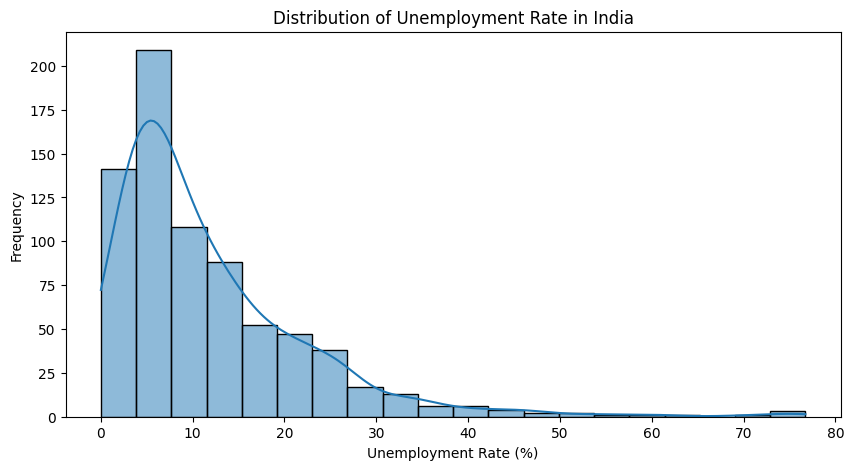

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Estimated Unemployment Rate (%)"],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate in India")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

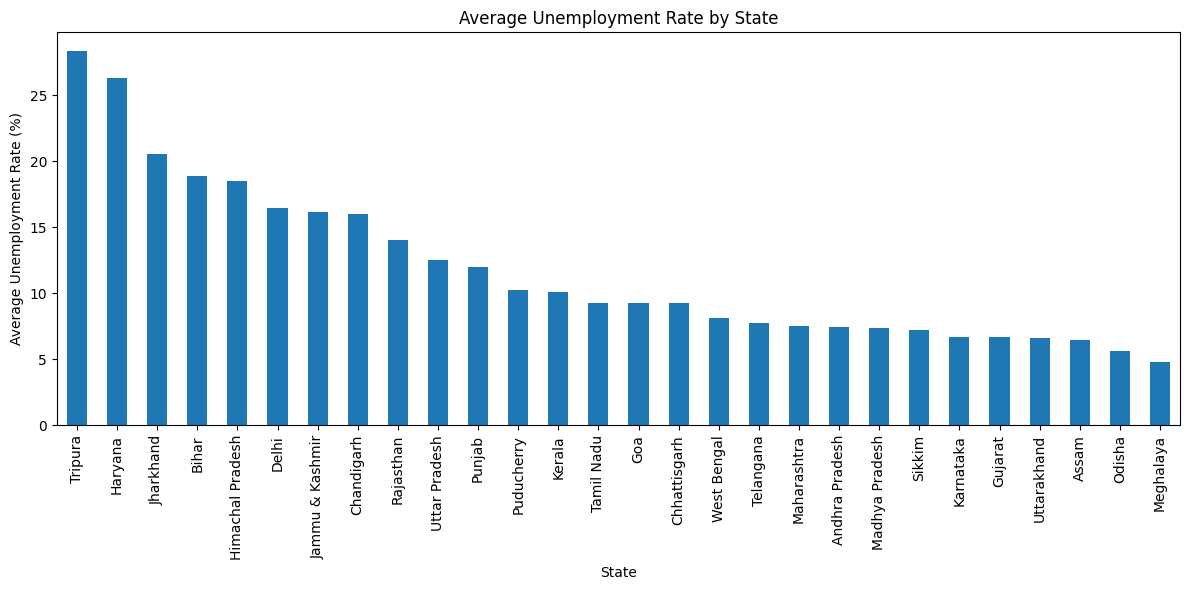

In [18]:
state_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()
state_avg = state_avg.sort_values(ascending=False)

plt.figure(figsize=(12, 6))

state_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by State")
plt.xlabel("State")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [19]:
top10 = state_avg.head(10)

print("Top 10 States with Highest Average Unemployment Rate:")
display(top10)

Top 10 States with Highest Average Unemployment Rate:


,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


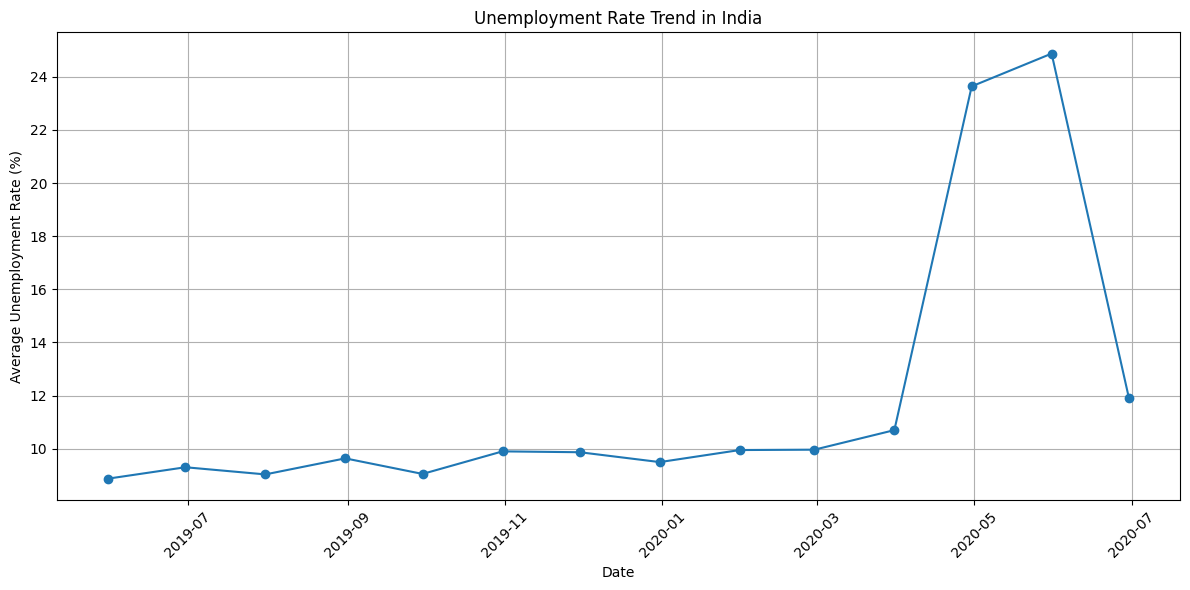

In [20]:
monthly_avg = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12, 6))

plt.plot(monthly_avg.index, monthly_avg.values, marker="o")

plt.title("Unemployment Rate Trend in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

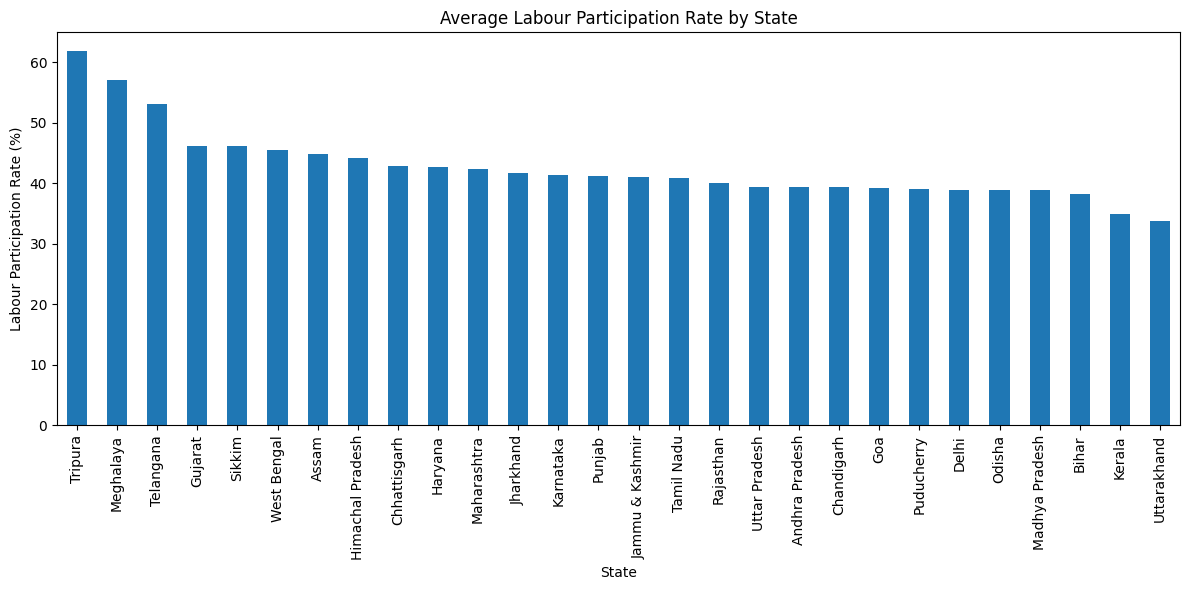

In [21]:
lpr_state = df.groupby("Region")["Estimated Labour Participation Rate (%)"].mean()
lpr_state = lpr_state.sort_values(ascending=False)

plt.figure(figsize=(12, 6))

lpr_state.plot(kind="bar")

plt.title("Average Labour Participation Rate by State")
plt.xlabel("State")
plt.ylabel("Labour Participation Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

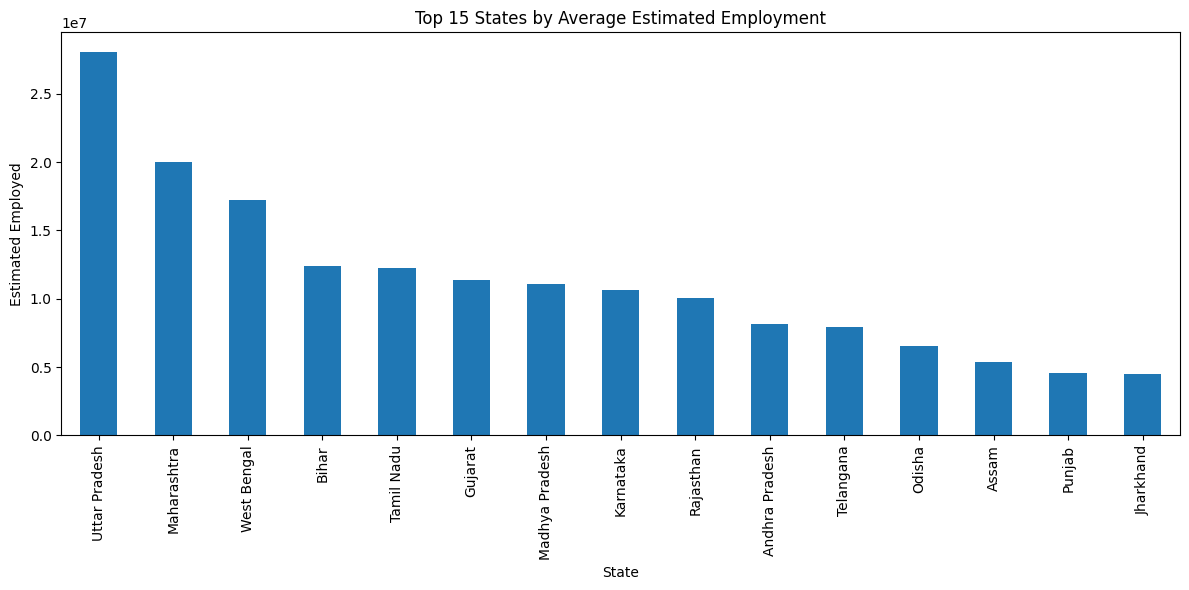

In [22]:
employment_state = df.groupby("Region")["Estimated Employed"].mean()
employment_state = employment_state.sort_values(ascending=False)

plt.figure(figsize=(12, 6))

employment_state.head(15).plot(kind="bar")

plt.title("Top 15 States by Average Estimated Employment")
plt.xlabel("State")
plt.ylabel("Estimated Employed")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

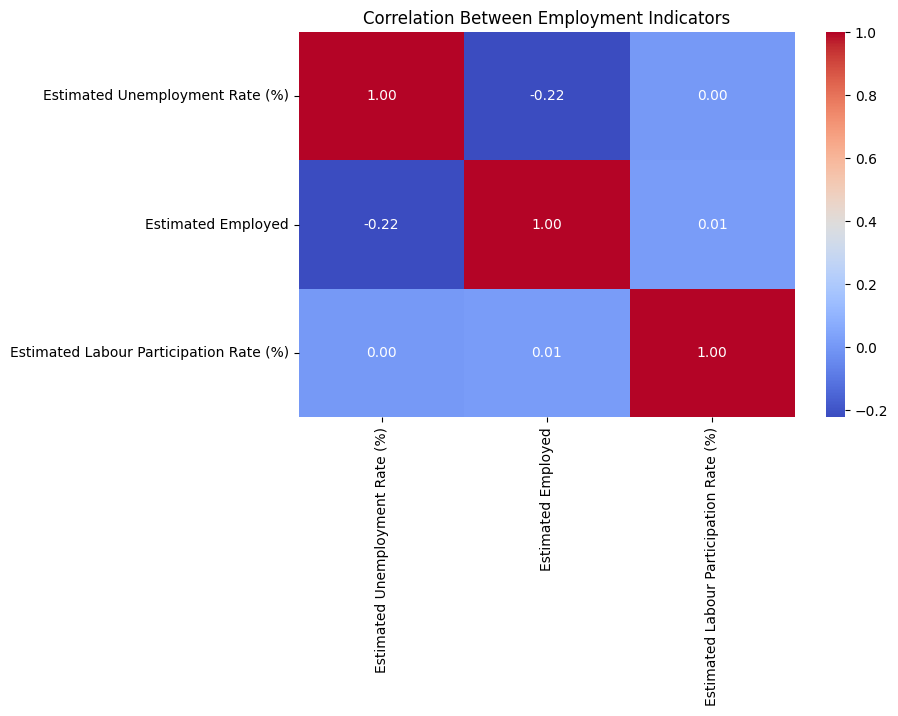

In [23]:
numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Employment Indicators")
plt.show()

In [24]:
highest_state = state_avg.idxmax()
highest_rate = state_avg.max()

lowest_state = state_avg.idxmin()
lowest_rate = state_avg.min()

print("Highest Average Unemployment:")
print(highest_state, "=", round(highest_rate, 2), "%")

print("\nLowest Average Unemployment:")
print(lowest_state, "=", round(lowest_rate, 2), "%")

Highest Average Unemployment:
Tripura = 28.35 %

Lowest Average Unemployment:
Meghalaya = 4.8 %


In [25]:
print("UNEMPLOYMENT IN INDIA - SUMMARY")
print("--------------------------------")

print(f"Highest unemployment state: {highest_state}")
print(f"Highest average unemployment rate: {highest_rate:.2f}%")

print(f"\nLowest unemployment state: {lowest_state}")
print(f"Lowest average unemployment rate: {lowest_rate:.2f}%")

print(f"\nAverage unemployment rate in dataset: "
      f"{df['Estimated Unemployment Rate (%)'].mean():.2f}%")

print(f"Average labour participation rate: "
      f"{df['Estimated Labour Participation Rate (%)'].mean():.2f}%")

UNEMPLOYMENT IN INDIA - SUMMARY
--------------------------------
Highest unemployment state: Tripura
Highest average unemployment rate: 28.35%

Lowest unemployment state: Meghalaya
Lowest average unemployment rate: 4.80%

Average unemployment rate in dataset: 11.79%
Average labour participation rate: 42.63%


## Conclusion

The analysis of the **Unemployment in India** dataset provided valuable insights into unemployment trends across different states and over different periods. The exploratory data analysis helped identify variations in unemployment rates, estimated employment, and labour participation rates among Indian states.

The visualizations showed that unemployment rates vary significantly across regions and time. The analysis also highlighted the relationship between unemployment and other employment-related indicators. State-wise comparisons helped identify regions with relatively higher and lower unemployment rates.

Overall, this project demonstrates how **Data Science, Data Analysis, and Data Visualization** techniques can be used to understand employment trends and extract meaningful insights from real-world datasets.
